In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

{}

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# **Collect Dataset**

In [9]:
!kaggle datasets download -d arnavjain1/glaucoma-datasets

!unzip glaucoma-datasets.zip -d glaucoma_dataset

Streaming output truncated to the last 5000 lines.
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0207.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0208.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0209.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0210.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0211.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0212.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0213.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0214.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0215.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0216.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0217.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0218.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0219.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0220.png

**File structure:**

+ glaucoma_dataset
  + G1020
    + Images
      - image_0.jpg
      - image_0.json
      - image_1.jpg
      - image_1.json
      
      .....
    + Images_Cropped
    + Image_Square
    + Masks
    + Masks_Cropped
    + Mask_Square
    + NerveRemoved_Images
    - G1020.CSV
  + ORIGA
    + Images
        - image_0.jpg
        - image_0.json
        - image_1.jpg
        - image_1.json
        
        .....
    + Images_Cropped
    + Image_Square
    + Masks
    + Masks_Cropped
    + Mask_Square
    + Semi-automatic-annotations
    - OrigaList.CSV
  + REFUGE
  + MODELS
    - refug_clf.pkl
    - refuge_segmentation.pth



# **Preprocessing Time**

In [10]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
from PIL import Image

In [31]:
SOURCE_PATH = "glaucoma_dataset"
DEST_PATH = "dataset"

classes = ["glaucoma", "normal"]
splits = ["train", "val", "test"]

In [32]:
# consider the RGB image for dataset
def convert_to_jpg(src_path, dst_path):
    img = Image.open(src_path).convert("RGB")
    dst_path = os.path.splitext(dst_path)[0] + ".jpg"
    img.save(dst_path, "JPEG", quality=95)

In [33]:
def process_dataset(source_folder, csv_file, output_root=DEST_PATH):

    csv_path = os.path.join(source_folder, csv_file)
    df = pd.read_csv(csv_path)

    print("\nProcessing:", source_folder)

    if "G1020" in source_folder:
        image_col = "imageID"
        label_col = "binaryLabels"
        images_folder = os.path.join(source_folder, "Images")

    elif "ORIGA" in source_folder:
        image_col = "Filename"
        label_col = "Glaucoma"
        images_folder = os.path.join(source_folder, "Images_Cropped")

    else:
        raise ValueError("Unknown dataset")

    images = df[image_col].astype(str).str.strip().values
    labels = df[label_col].astype(int).values

    # I am Separate small classes (less than 2 samples)
    class_counts = Counter(labels)
    print("Class Distribution:", class_counts)

    valid_images = []
    valid_labels = []

    # for img, lbl in zip(images, labels):
    #     img_path = os.path.join(images_folder, img)

    #     if os.path.exists(img_path):
    #         valid_images.append(img_path)
    #         valid_labels.append(lbl)

    extensions = [".jpg", ".jpeg", ".png", ".bmp"]

    for img, lbl in zip(images, labels):
        base_name = os.path.splitext(img)[0]
        found = False
        for ext in extensions:
            img_path = os.path.join(images_folder, base_name + ext)
            if os.path.exists(img_path):
                valid_images.append(img_path)
                valid_labels.append(lbl)
                found = True
                break
        if not found:
            print("Missing: ", img)

    print("Valid images found:", len(valid_images))

    class_counts = Counter(valid_labels)
    small_classes = [cls for cls, count in class_counts.items() if count < 2]

    print("Small classes:", small_classes)

    train_imgs, train_lbls = [], []
    valid_imgs, valid_lbls = [], []

    for img, lbl in zip(valid_images, valid_labels):
        if lbl in small_classes:
            train_imgs.append(img)
            train_lbls.append(lbl)
        else:
            valid_imgs.append(img)
            valid_lbls.append(lbl)

    # Train (60%)
    X_train, X_temp, y_train, y_temp = train_test_split(
        valid_imgs,
        valid_lbls,
        test_size=0.4,
        stratify=valid_lbls,
        random_state=42
    )

    # Validation (10%) and Test (30%)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.75,
        stratify=y_temp,
        random_state=42
    )

    # At last add small class samples fully to the train
    X_train += train_imgs
    y_train += train_lbls

    print(f"Train: {len(X_train)}")
    print(f"Validation: {len(X_val)}")
    print(f"Test: {len(X_test)}")

    for split in splits:
        for cls in classes:
            os.makedirs(os.path.join(output_root, split, cls), exist_ok=True)

    # just doing copy past samples (not touch the original)
    def copy_files(images, labels, split_name):
        for img, lbl in zip(images, labels):
            class_name = "glaucoma" if lbl == 1 else "normal"

            dst = os.path.join(
                output_root,
                split_name,
                class_name,
                os.path.basename(img)
            )

            ext = os.path.splitext(img)[1].lower()

            if ext in [".jpg", ".jpeg"]:
                shutil.copy(img, dst)
            elif ext in [".png", ".bmp", ".tiff"]: #changing it to RGB
                convert_to_jpg(img, dst)

    copy_files(X_train, y_train, "train")
    copy_files(X_val, y_val, "val")
    copy_files(X_test, y_test, "test")

    print("Dataset prepared successfully!")

In [34]:
# process_dataset(
#     os.path.join(SOURCE_PATH, "G1020"),
#     "G1020.csv",
#     "Images_Cropped"
# )

# process_dataset(
#     os.path.join(SOURCE_PATH, "ORIGA"),
#     "OrigaList.csv",
#     "origa_info.csv"
#     "Images_Cropped"
# )

# print("Dataset split into Train, Test, Val successfully!")

process_dataset(
    os.path.join(SOURCE_PATH, "G1020"),
    "G1020.csv"
)

process_dataset(
    os.path.join(SOURCE_PATH, "ORIGA"),
    "OrigaList.csv"
)

print("Dataset split into Train, Test, Val successfully!")


Processing: glaucoma_dataset/G1020
Class Distribution: Counter({np.int64(0): 724, np.int64(1): 296})
Valid images found: 1020
Small classes: []
Train: 612
Validation: 102
Test: 306
Dataset prepared successfully!

Processing: glaucoma_dataset/ORIGA
Class Distribution: Counter({np.int64(0): 482, np.int64(1): 168})
Valid images found: 650
Small classes: []
Train: 390
Validation: 65
Test: 195
Dataset prepared successfully!
Dataset split into Train, Test, Val successfully!


Not need, so i delete this:
  + Images_Cropped/
  + origa_info.csvImages_Cropped/


In [30]:
shutil.rmtree("Images_Cropped", ignore_errors=True)
shutil.rmtree("origa_info.csvImages_Cropped", ignore_errors=True)

**Download the Preprocessed Dataset**

In [24]:
from google.colab import files

shutil.make_archive("dataset", 'zip', "dataset")

files.download("dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Data Augmentaion for Variation**

In [35]:
import os
import random
from PIL import Image, ImageEnhance, ImageOps
import numpy as np

In [36]:
# augment iin only train/ folder
DATASET_PATH = "dataset/train"

In [37]:
def rotate(img):
    return img.rotate(random.choice([90, 180, 270]))

def flip(img):
    if random.random() > 0.5:
        return ImageOps.mirror(img)   # horizontal flip
    else:
        return ImageOps.flip(img)     # vertical flip

def brightness(img):
    enhancer = ImageEnhance.Brightness(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def contrast(img):
    enhancer = ImageEnhance.Contrast(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def color(img):
    enhancer = ImageEnhance.Color(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def add_noise(img):
    arr = np.array(img)
    noise = np.random.randint(0, 30, arr.shape, dtype='uint8')
    arr = np.clip(arr + noise, 0, 255)
    return Image.fromarray(arr)

augmentations = [rotate, flip, brightness, contrast, color, add_noise]


In [39]:
# def augment_dataset():
#     print("Augmenting start...")
#     for class_name in ["glaucoma", "normal"]:
#         class_path = os.path.join(DATASET_PATH, class_name)
#         print(f"Work on: {class_path}")

#         for img_name in os.listdir(class_path):
#             img_path = os.path.join(class_path, img_name)

#             if not img_name.lower().endswith(".jpg"):
#                 continue

#             img = Image.open(img_path).convert("RGB")

#             # i create 3 augmented copies per image
#             for i in range(3):
#                 aug_img = img.copy()

#                 # apply any 2 random augmentations
#                 for aug in random.sample(augmentations, 2):
#                     aug_img = aug(aug_img)

#                 new_name = f"aug_{i}_{img_name}"
#                 save_path = os.path.join(class_path, new_name)

#                 aug_img.save(save_path, "JPEG", quality=95)

#     print("Augmentation completed successfully!")

# augment_dataset()

## Class Balancing via Targeted Augmentation
def augment_dataset():
    print("Augmenting start...")
    for class_name in ["glaucoma", "normal"]:
        class_path = os.path.join(DATASET_PATH, class_name)
        print(f"\nWork on: {class_path}\n")

        if class_name == "glaucoma":
            num_copies = 3   # MORE copies
        else:
            num_copies = 1   # LESS copies

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            print(f"aug: {img_path}")

            if not img_name.lower().endswith(".jpg"):
                continue

            img = Image.open(img_path).convert("RGB")

            for i in range(num_copies):
                aug_img = img.copy()

                # apply any 2 random augmentations
                for aug in random.sample(augmentations, 2):
                    aug_img = aug(aug_img)

                new_name = f"aug_{i}_{img_name}"
                save_path = os.path.join(class_path, new_name)

                aug_img.save(save_path, "JPEG", quality=95)

    print("Augmentation completed successfully!")

augment_dataset()

Augmenting start...

Work on: dataset/train/glaucoma

aug: dataset/train/glaucoma/image_420.jpg
aug: dataset/train/glaucoma/image_2606.jpg
aug: dataset/train/glaucoma/507.jpg
aug: dataset/train/glaucoma/image_856.jpg
aug: dataset/train/glaucoma/image_2042.jpg
aug: dataset/train/glaucoma/623.jpg
aug: dataset/train/glaucoma/image_1579.jpg
aug: dataset/train/glaucoma/image_916.jpg
aug: dataset/train/glaucoma/image_3202.jpg
aug: dataset/train/glaucoma/image_3081.jpg
aug: dataset/train/glaucoma/image_2403.jpg
aug: dataset/train/glaucoma/233.jpg
aug: dataset/train/glaucoma/image_2412.jpg
aug: dataset/train/glaucoma/383.jpg
aug: dataset/train/glaucoma/image_1496.jpg
aug: dataset/train/glaucoma/228.jpg
aug: dataset/train/glaucoma/image_1526.jpg
aug: dataset/train/glaucoma/image_2047.jpg
aug: dataset/train/glaucoma/image_2861.jpg
aug: dataset/train/glaucoma/304.jpg
aug: dataset/train/glaucoma/641.jpg
aug: dataset/train/glaucoma/image_1715.jpg
aug: dataset/train/glaucoma/image_1893.jpg
aug: data

# **Data Distribution**

In [40]:
import os
import matplotlib.pyplot as plt

In [41]:
DATASET_PATH = "dataset"

splits = ["train", "val", "test"]
classes = ["glaucoma", "normal"]

labels = []
counts = []

for split in splits:
    for cls in classes:
        path = os.path.join(DATASET_PATH, split, cls)

        num_images = len([
            f for f in os.listdir(path)
            if f.lower().endswith(".jpg")
        ])

        labels.append(f"{split}/{cls}")
        counts.append(num_images)

print(f"labels: {labels},\nCounts: {counts}")

short_labels = ["Tr-G", "Tr-N", "Va-G", "Va-N", "Te-G", "Te-N"]


labels: ['train/glaucoma', 'train/normal', 'val/glaucoma', 'val/normal', 'test/glaucoma', 'test/normal'],
Counts: [1116, 1446, 47, 120, 138, 363]


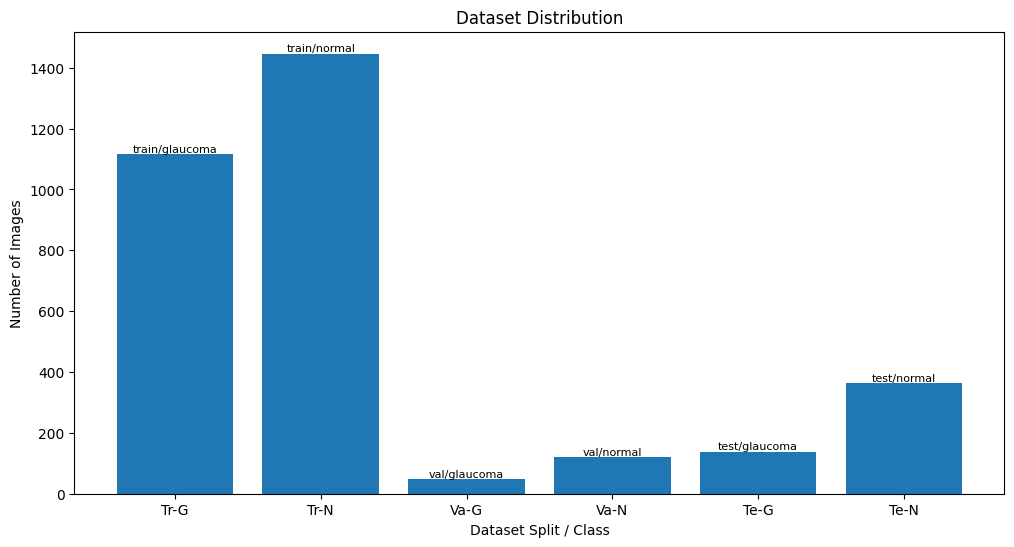

In [42]:
plt.figure(figsize=(12,6))

plt.bar(short_labels, counts)

plt.xlabel("Dataset Split / Class")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")

for i, txt in enumerate(labels):
    plt.text(i, counts[i], txt, ha='center', va='bottom', fontsize=8)

plt.show()

# **ROI Image Extraction and Mapping**

In [ ]:
import os
import shutil

In [43]:
DATASET_PATH = "dataset"
SOURCE_PATH = "glaucoma_dataset"

def find_roi_image(img_name):
    possible_paths = [
        # G1020 ROI locations :(
        os.path.join(SOURCE_PATH, "G1020", "Images_Cropped", img_name),
        os.path.join(SOURCE_PATH, "G1020", "Images_Cropped", "Images", img_name),

        # ORIGA ROI location
        os.path.join(SOURCE_PATH, "ORIGA", "Images_Cropped", img_name),
    ]

    for path in possible_paths:
        if os.path.exists(path):
            return path

    return None

def create_roi_dataset():
    print("Creating ROI dataset...")

    for split in ["train", "val", "test"]:
        for cls in ["glaucoma", "normal"]:
            print(f"Work on: {split}/{cls}")

            original_folder = os.path.join(DATASET_PATH, split, cls)
            roi_folder = os.path.join(DATASET_PATH, "roi", split, cls)

            os.makedirs(roi_folder, exist_ok=True)

            for img_name in os.listdir(original_folder):

                roi_img_path = find_roi_image(img_name)

                if roi_img_path is not None:
                    dst = os.path.join(roi_folder, img_name)
                    shutil.copy(roi_img_path, dst)

    print("ROI dataset created successfully!")

create_roi_dataset()

Creating ROI dataset...
Work on: train/glaucoma
Work on: train/normal
Work on: val/glaucoma
Work on: val/normal
Work on: test/glaucoma
Work on: test/normal
ROI dataset created successfully!


# **Define the ResNet50 Architecture**